In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df_2020 = pd.read_csv('data/df_2020_mit_labels.csv')
df_2021 = pd.read_csv('data/df_2021_mit_labels.csv')

In [3]:
df_2020

,system:index,B1_kurtosis,B1_max,B1_mean,B1_median,B1_min,B1_skew,B1_variance,B2_kurtosis,B2_max,...,cropland,grassland,herbaceous_wetland,mangroves,moss_lichen,shrubland,snow_ice,tree_cover,water,.geo
0,"6161,31656_6161,31656",-0.455765,314.0,276.699984,269.5,257.5,0.460239,167.635583,-1.256125,418.0,...,0.000000,0.473135,0.0,0.0,0.0,0.0,0.0,0.488868,0.037997,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
1,"6162,31656_6162,31656",-1.732772,334.0,284.308777,260.0,245.0,0.379515,1666.595989,-0.080641,415.0,...,0.000000,0.103138,0.0,0.0,0.0,0.0,0.0,0.896862,0.000000,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
2,"6161,31657_6161,31657",0.392692,314.0,264.183463,263.0,241.5,0.811400,378.444443,0.697992,434.5,...,0.000000,0.786500,0.0,0.0,0.0,0.0,0.0,0.189389,0.024111,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
3,"6162,31657_6162,31657",0.479508,321.0,268.415541,260.0,241.5,1.152794,564.506283,1.623456,687.0,...,0.000000,0.060918,0.0,0.0,0.0,0.0,0.0,0.939082,0.000000,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
4,"6163,31657_6163,31657",-1.748447,271.5,247.981950,234.5,234.5,0.501550,322.000000,-0.886488,585.5,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11719,"6119,31835_6119,31835",-1.832885,697.0,610.209840,662.0,533.0,-0.188013,4714.473600,10.619271,2578.0,...,0.473838,0.043325,0.0,0.0,0.0,0.0,0.0,0.008665,0.000000,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
11720,"6120,31835_6120,31835",-1.605249,736.0,710.772848,697.0,676.0,-0.117188,570.781191,6.593586,2622.0,...,0.384237,0.151987,0.0,0.0,0.0,0.0,0.0,0.005227,0.000000,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
11721,"6121,31835_6121,31835",-1.300244,676.0,606.453169,592.0,556.0,0.541182,2247.140496,-0.737941,778.0,...,0.902237,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
11722,"6122,31835_6122,31835",2.789566,556.0,520.194712,518.0,512.0,2.112366,192.801651,-0.167873,864.0,...,0.826461,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."


In [4]:
target_columns=[
 'bare_sparse_vegetation',
 'built_up',
 'cropland',
 'grassland',
 'herbaceous_wetland',
 'mangroves',
 'moss_lichen',
 'shrubland',
 'snow_ice',
 'tree_cover',
 'water'
 ]

In [6]:
df_2020[[
 'bare_sparse_vegetation',
 'built_up',
 'cropland',
 'grassland',
 'herbaceous_wetland',
 'mangroves',
 'moss_lichen',
 'shrubland',
 'snow_ice',
 'tree_cover',
 'water'
 ]]

,bare_sparse_vegetation,built_up,cropland,grassland,herbaceous_wetland,mangroves,moss_lichen,shrubland,snow_ice,tree_cover,water
0,0.000000,0.000000,0.000000,0.473135,0.0,0.0,0.0,0.0,0.0,0.488868,0.037997
1,0.000000,0.000000,0.000000,0.103138,0.0,0.0,0.0,0.0,0.0,0.896862,0.000000
2,0.000000,0.000000,0.000000,0.786500,0.0,0.0,0.0,0.0,0.0,0.189389,0.024111
3,0.000000,0.000000,0.000000,0.060918,0.0,0.0,0.0,0.0,0.0,0.939082,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
11719,0.303944,0.170228,0.473838,0.043325,0.0,0.0,0.0,0.0,0.0,0.008665,0.000000
11720,0.178793,0.279756,0.384237,0.151987,0.0,0.0,0.0,0.0,0.0,0.005227,0.000000
11721,0.097763,0.000000,0.902237,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
11722,0.173539,0.000000,0.826461,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


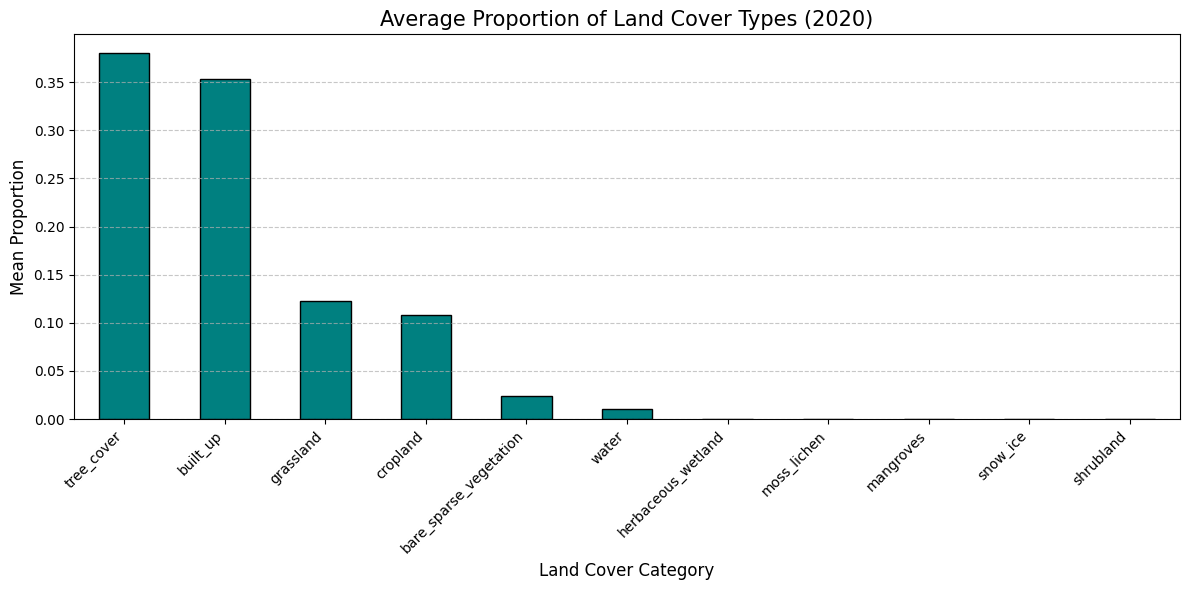

In [7]:
column_means = df_2020[target_columns].mean()

column_means_sorted = column_means.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
column_means_sorted.plot(kind='bar', color='teal', edgecolor='black')

# Add descriptive labels
plt.title('Average Proportion of Land Cover Types (2020)', fontsize=15)
plt.ylabel('Mean Proportion', fontsize=12)
plt.xlabel('Land Cover Category', fontsize=12)

plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add light grid lines
plt.tight_layout() # Ensure everything fits in the image

plt.show()

In [8]:
df_2020[[
 'bare_sparse_vegetation',
 'built_up',
 'cropland',
 'grassland',
 'herbaceous_wetland',
 'mangroves',
 'moss_lichen',
 'shrubland',
 'snow_ice',
 'tree_cover',
 'water'
 ]].describe()

,bare_sparse_vegetation,built_up,cropland,grassland,herbaceous_wetland,mangroves,moss_lichen,shrubland,snow_ice,tree_cover,water
count,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.0,11724.0,11724.0,11724.0,11724.000000,11724.000000
mean,0.023480,0.353596,0.108197,0.123147,0.000095,0.0,0.0,0.0,0.0,0.380674,0.010726
std,0.071798,0.355716,0.257449,0.213471,0.004223,0.0,0.0,0.0,0.0,0.364216,0.074863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.032623,0.000000
50%,0.000000,0.256896,0.000000,0.021078,0.000000,0.0,0.0,0.0,0.0,0.273443,0.000000
75%,0.007695,0.668961,0.001120,0.143515,0.000000,0.0,0.0,0.0,0.0,0.690501,0.000000
max,1.000000,1.000000,1.000000,1.000000,0.359159,0.0,0.0,0.0,0.0,1.000000,1.000000


In [3]:
df = pd.read_csv('/run/media/vaibhav/Projects/ML Project/nuremberg_2020_utm32_20m_s2bands_esa_labels.csv')

In [5]:
df.shape

(470811, 26)

In [9]:
df.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'bare_sparse_vegetation', 'built_up', 'cell_id', 'cropland',
       'grassland', 'image_count', 'lat', 'lon', 'tree_cover', 'utm_x',
       'utm_y', 'water', 'wc_label', 'year', '.geo'],
      dtype='str')

In [14]:
df['.geo']

0         {"geodesic":false,"crs":{"type":"name","proper...
1         {"geodesic":false,"crs":{"type":"name","proper...
2         {"geodesic":false,"crs":{"type":"name","proper...
3         {"geodesic":false,"crs":{"type":"name","proper...
4         {"geodesic":false,"crs":{"type":"name","proper...
                                ...                        
470806    {"geodesic":false,"crs":{"type":"name","proper...
470807    {"geodesic":false,"crs":{"type":"name","proper...
470808    {"geodesic":false,"crs":{"type":"name","proper...
470809    {"geodesic":false,"crs":{"type":"name","proper...
470810    {"geodesic":false,"crs":{"type":"name","proper...
Name: .geo, Length: 470811, dtype: str

In [13]:
df1['.geo'].iloc[0:1].to_string()

'0    {"geodesic":false,"crs":{"type":"name","proper...'

In [6]:
df1 = pd.read_csv('data/nuremberg_2020_20m_polygons.csv')

In [7]:
df1.shape

(466548, 22)

In [8]:
df1.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cell_id', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo'],
      dtype='str')